# Вариант TabBERT без отдельного history-энкодера

Этот ноутбук содержит альтернативную архитектурную постановку, где история транзакций обрабатывается не так, как в базовой иерархической схеме.

Ноутбук стоит воспринимать как отдельный экспериментальный вариант для сравнения с основной моделью. Название файла сохранено в исходном виде, чтобы не спутать его с уже существующими рабочими версиями и путями к локальным артефактам.

In [20]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertConfig, BertModel
from collections import Counter
import json
import os
from tqdm import tqdm
import random
import pickle

class TabBertVocabBuilder:
    """Класс для создания словаря признаков транзакций и границ бинов"""

    def __init__(self, df, categorical_columns, numerical_columns, special_tokens=None):
        """
        Args:
            df: DataFrame с транзакциями
            categorical_columns: список категориальных колонок
            numerical_columns: список числовых колонок
            special_tokens: специальные токены
        """
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns

        if special_tokens is None:
            self.special_tokens = ['[PAD]', '[CLS]', '[SEP]', '[MASK]', '[UNK]']
        else:
            self.special_tokens = special_tokens

        # Сохраняем границы бинов для каждой числовой колонки
        self.bin_edges = {}

        self.vocab = self._build_vocab(df)

    def _build_vocab(self, df):
        """Создание словаря из уникальных значений и границ бинов"""
        vocab_dict = {}

        # Добавляем специальные токены
        for i, token in enumerate(self.special_tokens):
            vocab_dict[token] = i

        current_idx = len(self.special_tokens)

        # Добавляем токены для категориальных колонок
        for col in self.categorical_columns:
            unique_values = df[col].astype(str).unique()
            for val in unique_values:
                token = f"{col}_{val}"
                if token not in vocab_dict:
                    vocab_dict[token] = current_idx
                    current_idx += 1
        return vocab_dict



    def save(self, path):
        """Сохранить словарь и границы бинов"""
        save_dict = {
            'vocab': self.vocab,
            'bin_edges': self.bin_edges,
            'categorical_columns': self.categorical_columns,
            'numerical_columns': self.numerical_columns,
            'special_tokens': self.special_tokens,
        }

        with open(path, 'wb') as f:
            pickle.dump(save_dict, f)
        print(f"TabBertVocab saved to {path}")

    @classmethod
    def load(cls, path):
        """Загрузить словарь и границы бинов"""
        with open(path, 'rb') as f:
            save_dict = pickle.load(f)

        # Создаем экземпляр без вычислений
        instance = cls.__new__(cls)
        instance.vocab = save_dict['vocab']
        instance.bin_edges = save_dict['bin_edges']
        instance.categorical_columns = save_dict['categorical_columns']
        instance.numerical_columns = save_dict['numerical_columns']
        instance.special_tokens = save_dict['special_tokens']

        print(f"TabBertVocab loaded from {path}. Size: {len(instance.vocab)}")
        return instance




In [ ]:

class TabBertTokenizer:
    """Токенизатор для табличных данных с поддержкой бинов"""

    def __init__(self, vocab_builder, max_length=128):
        """
        Args:
            vocab_builder: экземпляр TabBertVocabBuilder с сохраненными бинами
            max_length: максимальная длина последовательности
        """
        self.vocab_builder = vocab_builder
        self.vocab = vocab_builder.vocab
        self.max_length = max_length
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def tokenize_transaction(self, transaction_row, categorical_columns=None, numerical_columns=None):
        """
        Токенизация одной транзакции с использованием бинов для числовых значений

        Args:
            transaction_row: строка DataFrame с транзакцией
            categorical_columns: список категориальных колонок (если None, используются из vocab_builder)
            numerical_columns: список числовых колонок (если None, используются из vocab_builder)

        Returns:
            список токенов
        """
        if categorical_columns is None:
            categorical_columns = self.vocab_builder.categorical_columns
        if numerical_columns is None:
            numerical_columns = self.vocab_builder.numerical_columns

        tokens = ['[CLS]']  # Начинаем с CLS токена

        # Добавляем категориальные признаки
        for col in categorical_columns:
            if col in transaction_row.index:
                val = str(transaction_row[col]) if not pd.isna(transaction_row[col]) else 'missing'
                token = f"{col}_{val}"
                if token not in self.vocab:
                    token = '[UNK]'
                tokens.append(token)
            else:
                tokens.append('[UNK]')

        # Добавляем числовые признаки с использованием бинов
        for col in numerical_columns:
            if col in transaction_row.index:
                val = float(transaction_row[col])
                token = f"{col}_{val}"
            else:
                token = f"{col}_missing"

            tokens.append(token)

        tokens.append('[SEP]')
        return tokens

    def convert_tokens_to_ids(self, tokens):
        """Конвертация токенов в индексы"""
        ids = []
        for token in tokens:
            if token.split('_')[0] in self.vocab_builder.numerical_columns:
                ids.append(token)
            else:
                ids.append(self.vocab.get(token, self.vocab['[UNK]']))
        return ids

    def convert_ids_to_tokens(self, ids):
        """Конвертация индексов в токены"""
        tokens = []

        for id_one in ids:
            if str(id_one).split('_')[0] in self.vocab_builder.numerical_columns:
                tokens.append(id_one)
            else:
                tokens.append(self.inv_vocab.get(id_one, self.vocab['[UNK]']))
        return tokens


In [22]:
class TabBertTokenizer:
    """Токенизатор для табличных данных"""

    def __init__(self, vocab_builder, max_length=10):
        """
        Args:
            vocab_builder: экземпляр TabBertVocabBuilder
            max_length: максимальная длина последовательности
        """
        self.vocab_builder = vocab_builder
        self.vocab = vocab_builder.vocab
        self.max_length = max_length
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def tokenize_transaction(self, transaction_row, categorical_columns=None, numerical_columns=None):
        """
        Токенизация одной транзакции

        Returns:
            tuple: (categorical_ids, numerical_values, tokens) - 3 значения
        """
        if categorical_columns is None:
            categorical_columns = self.vocab_builder.categorical_columns
        if numerical_columns is None:
            numerical_columns = self.vocab_builder.numerical_columns

        tokens = ['[CLS]']  # Начинаем с CLS токена
        categorical_ids = [self.vocab.get('[CLS]')]
        numerical_values = []

        # Добавляем категориальные признаки
        for col in categorical_columns:
            if col in transaction_row.index:
                val = str(transaction_row[col]) if not pd.isna(transaction_row[col]) else 'missing'
                token = f"{col}_{val}"
                token_id = self.vocab.get(token, self.vocab['[UNK]'])
                tokens.append(token)
                categorical_ids.append(token_id)
            else:
                tokens.append('[UNK]')
                categorical_ids.append(self.vocab['[UNK]'])

        # Добавляем числовые признаки (исходные значения)
        for col in numerical_columns:
            if col in transaction_row.index and not pd.isna(transaction_row[col]):
                val = float(transaction_row[col])
                numerical_values.append(val)
                tokens.append(f"{col}_{val:.2f}")  # Для отладки
            else:
                numerical_values.append(0.0)  # Значение по умолчанию для пропущенных
                tokens.append(f"{col}_missing")

        tokens.append('[SEP]')
        categorical_ids.append(self.vocab.get('[SEP]'))

        # Обрезаем до max_length если нужно
        if len(tokens) > self.max_length:
            tokens = tokens[:self.max_length]
            categorical_ids = categorical_ids[:self.max_length - 1]
            numerical_values = numerical_values[:self.max_length - 1]

        # Добавляем PAD до max_length
        current_len = len(tokens)
        if current_len < self.max_length:
            padding_len = self.max_length - current_len
            tokens += ['[PAD]'] * padding_len
            categorical_ids += [self.vocab['[PAD]']] * padding_len
            numerical_values += [0.0] * padding_len

        # Возвращаем 3 значения: categorical_ids, numerical_values, tokens
        return categorical_ids, numerical_values, tokens

    def convert_tokens_to_ids(self, tokens):
        """Конвертация токенов в индексы"""
        ids = []
        for token in tokens:
            ids.append(self.vocab.get(token, self.vocab['[UNK]']))
        return ids

    def convert_ids_to_tokens(self, ids):
        """Конвертация индексов в токены"""
        tokens = []
        for id_one in ids:
            tokens.append(self.inv_vocab.get(id_one, '[UNK]'))
        return tokens

In [ ]:
import pandas as pd

df = pd.read_csv('card_transaction.v1.prepare.csv')

In [24]:
df.head(2)

,user,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,is_fraud,hour,minute,timestamp,isrefund
0,0,0,2002,9,1,06:21,134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,0,6,21,1030861260000000000,1
1,0,0,2002,9,1,06:42,38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,0,6,42,1030862520000000000,1


In [6]:
# categorical_columns = ['user_id', 'Card', 'Year', 'Month' , 'Day', 'hour', 'minute',  'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'is_refund']
categorical_columns = ['user', 'Card',  'Month' , 'Day', 'hour', 'minute',  'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'isrefund']
numerical_columns = ['Amount']


# vocab_builder = TabBertVocabBuilder(df, categorical_columns, numerical_columns)
# vocab_builder.save('tabbert_v7/tabbert_vocab_all.pkl')



vocab_builder = TabBertVocabBuilder.load('tabbert_v7/tabbert_vocab_all.pkl')

tokenizer = TabBertTokenizer(vocab_builder, max_length=32)





TabBertVocab loaded from tabbert_v7/tabbert_vocab_all.pkl. Size: 143597


In [ ]:
import torch.nn.functional as F


class TabBertForFraudDetection(nn.Module):
    def __init__(self, vocab_size, field_ranges, inv_vocab, num_numerical_features=1, hidden_size=128,
                 num_classes=2, max_history=10, freeze_first_bert=True, num_hidden_layers=6,
                 max_position_embeddings=1024):
        super().__init__()

        # Параметры оставлены совместимыми с прежним классом.
        self.field_ranges = field_ranges
        self.inv_vocab = inv_vocab
        self.hidden_size = hidden_size
        self.num_numerical_features = num_numerical_features
        self.max_history = max_history
        self.freeze_first_bert = freeze_first_bert

        self.cat_embedding = nn.Embedding(vocab_size, hidden_size)
        self.num_projection = nn.Linear(num_numerical_features, hidden_size)
        self.num_head = nn.Linear(hidden_size, num_numerical_features)

        # Один общий transformer вместо transaction_bert + history_bert.

        config = BertConfig(
            hidden_size=hidden_size,
            num_hidden_layers=num_hidden_layers,
            num_attention_heads=4,
            intermediate_size=hidden_size * 4,
            max_position_embeddings=max_position_embeddings,
            type_vocab_size=2,
            hidden_dropout_prob=0.3,
            attention_probs_dropout_prob=0.3
        )
        self.transformer = BertModel(config)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, num_classes)
        )

        self.mlm_head = nn.Linear(hidden_size, vocab_size)
        self.register_buffer('class_weights', torch.tensor([1.0, 5.0]))

    def _make_field_inputs(self, cat_ids, num_values, attention_mask):
        """Собирает поля транзакций в одну последовательность для общего transformer."""
        cat_embeds = self.cat_embedding(cat_ids)
        num_embeds = self.num_projection(num_values).unsqueeze(-2)
        field_embeddings = torch.cat([cat_embeds, num_embeds], dim=-2)

        valid_transaction = attention_mask.sum(dim=-1, keepdim=True) > 0
        num_mask = valid_transaction.to(dtype=attention_mask.dtype)
        field_mask = torch.cat([attention_mask, num_mask], dim=-1)

        return field_embeddings, field_mask

    def _encode_field_sequence(self, cat_ids, num_values, attention_mask):
        """Кодирует окно транзакций одним transformer: [batch, seq_len, fields, hidden_size]."""
        batch_size, seq_len = cat_ids.shape[:2]
        num_total_fields = cat_ids.size(-1) + 1

        field_embeddings, field_mask = self._make_field_inputs(cat_ids, num_values, attention_mask)
        transformer_inputs = field_embeddings.reshape(
            batch_size,
            seq_len * num_total_fields,
            self.hidden_size
        )
        transformer_mask = field_mask.reshape(batch_size, seq_len * num_total_fields)

        max_positions = self.transformer.config.max_position_embeddings
        if transformer_inputs.size(1) > max_positions:
            raise ValueError(
                f"Sequence length {transformer_inputs.size(1)} exceeds max_position_embeddings={max_positions}. "
                "Increase max_position_embeddings when creating the model."
            )

        outputs = self.transformer(
            inputs_embeds=transformer_inputs,
            attention_mask=transformer_mask
        )

        return outputs.last_hidden_state.reshape(
            batch_size,
            seq_len,
            num_total_fields,
            self.hidden_size
        )

    def _encode_cls_sequence(self, cat_ids, num_values, attention_mask):
        """CLS-представление каждой транзакции в окне: [batch, seq_len, hidden_size]."""
        field_embeddings = self._encode_field_sequence(cat_ids, num_values, attention_mask)
        return field_embeddings[:, :, 0, :]

   

    def forward_mlm(self, current_cat_ids, current_num_values, current_mask,
                    current_cat_labels, current_num_labels):
        """MLM forward без истории: кодируется только текущая транзакция."""
        field_embeddings = self._encode_field_sequence(
            current_cat_ids.unsqueeze(1),
            current_num_values.unsqueeze(1),
            current_mask.unsqueeze(1)
        )

        cat_embeddings = field_embeddings[:, 0, :-1, :]
        num_embeddings = field_embeddings[:, 0, -1, :]

        prediction_scores = self.mlm_head(cat_embeddings)
        num_scores = self.num_head(num_embeddings)

        return prediction_scores, num_scores, current_cat_labels, current_num_labels

    def forward(
        self,
        cat_ids,
        num_values,
        attention_mask,
        labels=None,

    ):
        """Classification forward; опционально supervised NT-Xent (негативы другого класса, см. static method)."""
        sequence_output = self._encode_cls_sequence(cat_ids, num_values, attention_mask)
        batch_size, seq_len, _ = sequence_output.shape

        logits = self.classifier(sequence_output.reshape(-1, self.hidden_size))
        logits = logits.reshape(batch_size, seq_len, -1)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            active_loss = (labels != -100).view(-1)
            active_logits = logits.view(-1, logits.size(-1))[active_loss]
            active_labels = labels.view(-1)[active_loss]
            loss = loss_fn(active_logits, active_labels)

        return loss, logits

In [8]:
field_ranges = {'user': {'min': 5, 'max': 2004, 'size': 2000},
 'Card': {'min': 2005, 'max': 2013, 'size': 9},
 'Month': {'min': 2014, 'max': 2025, 'size': 12},
 'Day': {'min': 2026, 'max': 2056, 'size': 31},
 'hour': {'min': 2057, 'max': 2080, 'size': 24},
 'minute': {'min': 2081, 'max': 2140, 'size': 60},
 'Use Chip': {'min': 2141, 'max': 2143, 'size': 3},
 'Merchant Name': {'min': 2144, 'max': 102486, 'size': 100343},
 'Merchant City': {'min': 102487, 'max': 115915, 'size': 13429},
 'Merchant State': {'min': 115916, 'max': 116139, 'size': 224},
 'Zip': {'min': 116140, 'max': 143461, 'size': 27322},
 'MCC': {'min': 143462, 'max': 143570, 'size': 109},
 'Errors?': {'min': 143571, 'max': 143594, 'size': 24},
 'isrefund': {'min': 143595, 'max': 143596, 'size': 2}}

inv_vocab = {v: k for k, v in vocab_builder.vocab.items()}

In [ ]:
mlm_model = TabBertForFraudDetection(
    len(vocab_builder.vocab),
    field_ranges=field_ranges,
    inv_vocab=inv_vocab,
    hidden_size=128
)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

save_path = 'tabbert_new/tabbert_model_mlm_no_history_epoch_4.pth'
checkpoint = torch.load(save_path, map_location='cpu')
mlm_model.load_state_dict(checkpoint['model_state_dict'])


mlm_model = mlm_model.to(device)  # Явный перенос на CUDA


Using device: cuda


In [18]:
class TabBertMLMDataset(Dataset):
    """MLM Dataset без истории: один sample = одна транзакция."""

    def __init__(self, df, tokenizer, categorical_columns, numerical_columns,
                 max_seq_length=128, mask_prob=0.15):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns
        self.max_seq_length = max_seq_length
        self.mask_prob = mask_prob

        self.cls_id = self.tokenizer.vocab['[CLS]']
        self.sep_id = self.tokenizer.vocab['[SEP]']
        self.pad_id = self.tokenizer.vocab['[PAD]']
        self.unk_id = self.tokenizer.vocab['[UNK]']
        self.mask_id = self.tokenizer.vocab['[MASK]']
        self.vocab_size = len(self.tokenizer.vocab)
        self.num_numerical_features = len(self.numerical_columns)
        self.special_ids = {self.cls_id, self.sep_id, self.pad_id}

        used_columns = list(dict.fromkeys(self.categorical_columns + self.numerical_columns))
        self.column_arrays = {
            col: self.df[col].to_numpy(copy=False) for col in used_columns
        }

        self.current_indices = np.arange(len(self.df), dtype=np.int64)

        self.pad_cat_ids = np.full(self.max_seq_length, self.pad_id, dtype=np.int64)
        self.pad_num_values = np.zeros(self.num_numerical_features, dtype=np.float32)
        self.pad_mask = np.zeros(self.max_seq_length, dtype=np.int64)

        self.cat_value_to_id = {col: {} for col in self.categorical_columns}
        for token, token_id in self.tokenizer.vocab.items():
            if token.startswith('['):
                continue

            for col in self.categorical_columns:
                prefix = f"{col}_"
                if token.startswith(prefix):
                    self.cat_value_to_id[col][token[len(prefix):]] = token_id
                    break

        print(f"Создано {len(self.current_indices)} транзакций из {len(df)} строк")

    def __len__(self):
        return len(self.current_indices)

    def _tokenize_transaction(self, idx):
        cat_ids = self.pad_cat_ids.copy()
        num_values = self.pad_num_values.copy()
        mask = self.pad_mask.copy()

        write_pos = 0
        cat_ids[write_pos] = self.cls_id
        write_pos += 1

        for col in self.categorical_columns:
            if write_pos >= self.max_seq_length - 1:
                break

            value = self.column_arrays[col][idx]
            if pd.isna(value):
                token_id = self.unk_id
            else:
                token_id = self.cat_value_to_id[col].get(str(value), self.unk_id)

            cat_ids[write_pos] = token_id
            write_pos += 1

        if write_pos < self.max_seq_length:
            cat_ids[write_pos] = self.sep_id
            write_pos += 1

        mask[:write_pos] = 1

        for num_idx, col in enumerate(self.numerical_columns):
            value = self.column_arrays[col][idx]
            num_values[num_idx] = 0.0 if pd.isna(value) else float(value)

        return cat_ids, num_values, mask

    def _apply_masking(self, cat_ids, num_values):
        masked_cat_ids = cat_ids.copy()
        cat_labels = np.full_like(cat_ids, fill_value=-100)
        masked_num_values = num_values.copy()
        num_labels = num_values.copy().astype(np.float32)

        for i, token_id in enumerate(cat_ids):
            if token_id in self.special_ids or token_id == self.unk_id:
                continue

            if random.random() < self.mask_prob:
                cat_labels[i] = token_id

                r = random.random()
                if r < 0.8:
                    masked_cat_ids[i] = self.mask_id
                elif r < 0.9:
                    masked_cat_ids[i] = random.randint(0, self.vocab_size - 1)

        return masked_cat_ids, cat_labels, masked_num_values, num_labels

    def __getitem__(self, idx):
        current_idx = int(self.current_indices[idx])

        current_cat_ids, current_num_values, current_mask = self._tokenize_transaction(current_idx)
        masked_current_cat_ids, current_cat_labels, masked_current_num_values, current_num_labels = (
            self._apply_masking(current_cat_ids, current_num_values)
        )

        return {
            'current_cat_ids': torch.from_numpy(masked_current_cat_ids).long(),
            'current_num_values': torch.from_numpy(masked_current_num_values).float(),
            'current_mask': torch.from_numpy(current_mask).long(),
            'current_cat_labels': torch.from_numpy(current_cat_labels).long(),
            'current_num_labels': torch.from_numpy(current_num_labels).float(),
        }

In [19]:
print("Creating MLM dataset...")

full_dataset = TabBertMLMDataset(
    df, tokenizer, categorical_columns, numerical_columns,  max_seq_length=18
)

Creating MLM dataset...
Создано 24386900 транзакций из 24386900 строк


In [21]:
import os

# Разделяем на train и val (например, 80/20)
from torch.utils.data import random_split

torch.manual_seed(42)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Total samples: {len(full_dataset)}")
print(f"Train samples: {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Val samples: {len(val_dataset)} ({len(val_dataset)/len(full_dataset)*100:.1f}%)")

# Для машины с 10 CPU cores обычно разумно оставить 2 ядра системе и остальное отдать DataLoader.
AVAILABLE_CPU = os.cpu_count() or 2
NUM_WORKERS = min(8, max(2, AVAILABLE_CPU - 2))
BATCH_SIZE = 512
PIN_MEMORY = device.type == 'cuda'

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'persistent_workers': NUM_WORKERS > 0,
    'drop_last': False
}

if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 4

mlm_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs
)

mlm_val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

print(f"\nCPU cores available: {AVAILABLE_CPU}")
print(f"Using DataLoader workers: {NUM_WORKERS}")
print(f"Train batches: {len(mlm_loader)}")
print(f"Val batches: {len(mlm_val_loader)}")

Total samples: 24386900
Train samples: 19509520 (80.0%)
Val samples: 4877380 (20.0%)

CPU cores available: 44
Using DataLoader workers: 8
Train batches: 38105
Val batches: 9527


In [30]:
# del mlm_loader, mlm_val_loader

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def calculate_categorical_cross_entropy(prediction_scores, current_cat_labels, field_ranges):
    """
    Расчет кросс-энтропии для категориальных признаков

    Args:
        prediction_scores: torch.Tensor [batch_size, num_fields, vocab_size]
        current_cat_labels: torch.Tensor [batch_size, num_fields]
        field_ranges: dict с диапазонами индексов для каждого поля

    Returns:
        total_ce: средняя кросс-энтропия по всем категориальным полям
        field_ces: dict с CE для каждого поля
    """
    # Исключаем числовое поле
    cat_field_indices = [i for i, field_name in enumerate(field_ranges.keys())
                         if field_name != 'amount']

    total_ce = 0.0
    field_ces = {}

    for field_idx, field_name in enumerate(field_ranges.keys()):
        if field_name == 'amount':  # пропускаем числовое поле
            continue

        field_info = field_ranges[field_name]
        start_idx = field_info['min']
        end_idx = field_info['max']

        # Извлекаем логиты для этого поля [batch_size, field_size]
        field_logits = prediction_scores[:, field_idx, start_idx:end_idx+1]

        # Получаем целевые метки [batch_size]
        field_labels = current_cat_labels[:, field_idx]

        # Приводим метки к локальным индексам в рамках поля
        local_labels = field_labels - start_idx

        # Вычисляем кросс-энтропию
        ce = F.cross_entropy(field_logits, local_labels, reduction='mean')
        total_ce += ce
        field_ces[field_name] = ce.item()

    return total_ce / len(cat_field_indices), field_ces


def calculate_mse(num_scores, current_num_labels):
    """
    Расчет MSE для числового признака

    Args:
        num_scores: torch.Tensor [batch_size, 1] или [batch_size]
        current_num_labels: torch.Tensor [batch_size]

    Returns:
        mse: средняя квадратичная ошибка
    """
    # Если num_scores приходит как [batch_size, 1], убираем лишнюю размерность
    if num_scores.dim() == 2 and num_scores.size(1) == 1:
        numeric_predictions = num_scores.squeeze(-1)  # [batch_size]
    else:
        numeric_predictions = num_scores  # [batch_size]

    # Вычисляем MSE
    mse_loss = nn.MSELoss()
    mse = mse_loss(numeric_predictions, current_num_labels)

    return mse


def calculate_all_metrics(prediction_scores, num_scores, current_cat_labels,
                          current_num_labels, field_ranges):
    """
    Расчет всех метрик

    Args:
        prediction_scores: [batch_size, num_fields, vocab_size]
        num_scores: [batch_size, num_fields, 1]
        current_cat_labels: [batch_size, num_fields]
        current_num_labels: [batch_size]
        field_ranges: dict с диапазонами полей

    Returns:
        dict со всеми метриками
    """
    # Кросс-энтропия для категориальных признаков
    avg_ce, field_ces = calculate_categorical_cross_entropy(
        prediction_scores, current_cat_labels, field_ranges
    )

    # MSE для числового признака
    mse = calculate_mse(num_scores, current_num_labels)

    return {
        'avg_categorical_ce': avg_ce,
        'field_ces': field_ces,
        'mse': mse,
        'total_loss': avg_ce + mse
    }



In [23]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from IPython.display import clear_output

class NumericalNormalizer:
    """Класс для нормализации числовых значений"""
    def __init__(self, min_val=None, max_val=None, mean=None, std=None):
        self.min_val = min_val
        self.max_val = max_val
        self.mean = mean
        self.std = std
        self.method = 'minmax' if min_val is not None else 'standard'

    def normalize(self, x):
        """Нормализация"""
        if self.method == 'minmax':
            # Min-Max нормализация: [min, max] -> [0, 1]
            return (x - self.min_val) / (self.max_val - self.min_val)
        elif self.method == 'standard':
            # Стандартизация: mean=0, std=1
            return (x - self.mean) / (self.std)
        return x

    def denormalize(self, x):
        """Обратная нормализация"""
        if self.method == 'minmax':
            return x * (self.max_val - self.min_val) + self.min_val
        elif self.method == 'standard':
            return x * self.std + self.mean
        return x

    def to(self, device):
        """Перенос статистик на устройство"""
        if self.min_val is not None:
            self.min_val = torch.tensor(self.min_val, device=device)
            self.max_val = torch.tensor(self.max_val, device=device)
        if self.mean is not None:
            self.mean = torch.tensor(self.mean, device=device)
            self.std = torch.tensor(self.std, device=device)
        return self

# Создаем нормализатор для числового поля
# Вычислите min и max из ваших данных
numerical_min = 0.01  # замените на реальный минимум
numerical_max = 12390.5  # замените на реальный максимум
# df.Amount.mean(), df.Amount.std()
# Или используйте mean и std
numerical_mean = df.Amount.mean()
numerical_std = df.Amount.std()

# num_normalizer = NumericalNormalizer(min_val=numerical_min, max_val=numerical_max)
# Или для стандартизации:
num_normalizer = NumericalNormalizer(mean=numerical_mean, std=numerical_std)

# Переносим на устройство
num_normalizer.to(device)
def calculate_mlm_loss(prediction_scores, all_cat_labels, num_scores, all_num_labels, 
                       field_ranges, num_normalizer=None, num_fields=7):
    """
    MLM loss для модели без исторической размерности.
    
    Args:
        prediction_scores: [batch, num_cat_fields, global_vocab_size]
        all_cat_labels: [batch, num_cat_fields] - уже в локальных индексах [0, local_size-1]
        num_scores: [batch, 1]
        all_num_labels: [batch, 1]
        field_ranges: словарь с min/max для каждого поля
        num_normalizer: нормализатор для числовых значений
    
    Returns:
        total_loss, avg_cat_loss, num_loss, cat_losses_per_field
    """
    
    # Получаем список категориальных полей
    cat_field_names = [field_name for field_name in field_ranges.keys() if field_name != 'amount']
    
    total_cat_loss = 0.0
    cat_losses_per_field = {}
    cat_valid_count = 0
    
    # ========== КАТЕГОРИАЛЬНАЯ ПОТЕРЯ ==========
    for field_idx, field_name in enumerate(cat_field_names):
        # Получаем диапазон значений для текущего поля
        field_info = field_ranges[field_name]
        start_idx = field_info['min']
        end_idx = field_info['max']
        local_vocab_size = end_idx - start_idx + 1
        
        # Извлекаем данные для этого поля
        field_logits = prediction_scores[:, field_idx, :]  # [batch, global_vocab_size]
        field_labels = all_cat_labels[:, field_idx]        # [batch] - УЖЕ локальные!
        
        # Маска валидных предсказаний
        valid_mask = (field_labels != -100)
        
        if valid_mask.any():
            # Обрезаем логиты до нужного диапазона
            local_logits = field_logits[valid_mask, start_idx:end_idx+1]  # [num_valid, local_vocab_size]
            
            # НЕ ВЫЧИТАЕМ start_idx, так как метки уже локальные!
            local_labels = field_labels[valid_mask]  # [num_valid]
            
            # Проверяем корректность меток
            if (local_labels >= 0).all() and (local_labels < local_vocab_size).all():
                field_loss = F.cross_entropy(local_logits, local_labels, reduction='mean')
                total_cat_loss += field_loss
                cat_losses_per_field[field_name] = field_loss.item()
                cat_valid_count += 1
            else:
                # Пропускаем некорректные метки
                valid_local_mask = (local_labels >= 0) & (local_labels < local_vocab_size)
                if valid_local_mask.any():
                    local_logits_filtered = local_logits[valid_local_mask]
                    local_labels_filtered = local_labels[valid_local_mask]
                    field_loss = F.cross_entropy(local_logits_filtered, local_labels_filtered, reduction='mean')
                    total_cat_loss += field_loss
                    cat_losses_per_field[field_name] = field_loss.item()
                    cat_valid_count += 1
    
    # Усредняем категориальную потерю
    avg_cat_loss = (
        total_cat_loss / cat_valid_count
        if cat_valid_count > 0
        else torch.tensor(0.0, device=prediction_scores.device)
    )
    
    # ========== ЧИСЛОВАЯ ПОТЕРЯ ==========
    num_scores = num_scores.squeeze(-1)        # [batch]
    all_num_labels = all_num_labels.squeeze(-1)  # [batch]
    
    num_valid_mask = (all_num_labels != -100)
    
    if num_valid_mask.any():
        active_num_pred = num_scores[num_valid_mask]
        active_num_target = all_num_labels[num_valid_mask]
        
        if num_normalizer is not None:
            active_num_target_normalized = num_normalizer.normalize(active_num_target)
            num_loss = F.mse_loss(active_num_pred, active_num_target_normalized, reduction='mean')
        else:
            num_loss = F.mse_loss(active_num_pred, active_num_target, reduction='mean')
    else:
        num_loss = torch.tensor(0.0, device=num_scores.device)
    
    # ========== ИТОГОВАЯ ПОТЕРЯ ==========
    cat_weight = 1.0
    num_weight = 1.0
    total_loss = cat_weight * avg_cat_loss + num_weight * num_loss
    
    return total_loss, avg_cat_loss, num_loss, cat_losses_per_field


def calculate_numerical_metrics_normalized(num_scores, all_num_labels, num_normalizer):
    """
    Расчет метрик для числового поля с денормализацией
    """
    print("\n" + "="*70)
    print("📊 ЧИСЛОВЫЕ МЕТРИКИ (с нормализацией)")
    print("="*70)

    # Убираем лишние размерности
    num_scores = num_scores.squeeze(-1)  # [batch, total_transactions]
    all_num_labels = all_num_labels.squeeze(-1)  # [batch, total_transactions]

    # Маска валидных предсказаний
    valid_mask = (all_num_labels != -100)

    if not valid_mask.any():
        print("⚠️ Нет валидных предсказаний для числового поля")
        return {
            'mse': torch.tensor(0.0),
            'mae': torch.tensor(0.0),
            'rmse': torch.tensor(0.0),
            'mse_normalized': torch.tensor(0.0),
            'mae_normalized': torch.tensor(0.0),
            'valid_count': 0
        }

    active_predictions = num_scores[valid_mask]
    active_targets = all_num_labels[valid_mask]

    # Нормализуем целевые значения для расчета loss
    active_targets_normalized = num_normalizer.normalize(active_targets)

    # Метрики на НОРМАЛИЗОВАННЫХ значениях
    mse_norm = F.mse_loss(active_predictions, active_targets_normalized, reduction='mean')
    mae_norm = torch.abs(active_predictions - active_targets_normalized).mean()
    rmse_norm = torch.sqrt(mse_norm)

    # 🔥 ДЕНОРМАЛИЗУЕМ предсказания для метрик в исходном масштабе
    active_predictions_denorm = num_normalizer.denormalize(active_predictions)

    # Метрики в ИСХОДНОМ масштабе
    mse = F.mse_loss(active_predictions_denorm, active_targets, reduction='mean')
    mae = torch.abs(active_predictions_denorm - active_targets).mean()
    rmse = torch.sqrt(mse)

    # Дополнительная статистика
    pred_min = active_predictions_denorm.min().item()
    pred_max = active_predictions_denorm.max().item()
    pred_mean = active_predictions_denorm.mean().item()

    target_min = active_targets.min().item()
    target_max = active_targets.max().item()
    target_mean = active_targets.mean().item()

    print(f"\n{'Метрика':<25} {'Нормализованные':<20} {'Исходный масштаб':<20}")
    print("-"*65)
    print(f"{'MSE':<25} {mse_norm.item():<20.6f} {mse.item():<20.2f}")
    print(f"{'MAE':<25} {mae_norm.item():<20.6f} {mae.item():<20.2f}")
    print(f"{'RMSE':<25} {rmse_norm.item():<20.6f} {rmse.item():<20.2f}")
    print(f"{'Валидных предсказаний':<25} {valid_mask.sum().item():<20}")
    print()
    print(f"{'Статистика (исходный масштаб)':<25}")
    print(f"{'Min предсказаний':<25} {pred_min:<20.2f}")
    print(f"{'Max предсказаний':<25} {pred_max:<20.2f}")
    print(f"{'Mean предсказаний':<25} {pred_mean:<20.2f}")
    print(f"{'Min целевых':<25} {target_min:<20.2f}")
    print(f"{'Max целевых':<25} {target_max:<20.2f}")
    print(f"{'Mean целевых':<25} {target_mean:<20.2f}")
    print("="*70)

    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'mse_normalized': mse_norm,
        'mae_normalized': mae_norm,
        'rmse_normalized': rmse_norm,
        'valid_count': valid_mask.sum().item(),
        'predictions_stats': {
            'min': pred_min,
            'max': pred_max,
            'mean': pred_mean
        },
        'targets_stats': {
            'min': target_min,
            'max': target_max,
            'mean': target_mean
        }
    }


def plot_all_losses_normalized(train_total, val_total, train_cat, val_cat, train_num, val_num,
                               train_num_denorm=None, val_num_denorm=None):
    """Графики всех потерь с возможностью показа денормализованных числовых потерь"""
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Общий loss
    axes[0].plot(train_total, label="Train", color='blue')
    axes[0].plot(val_total, label="Val", color='orange')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Total Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Категориальные потери
    axes[1].plot(train_cat, label="Train", color='green')
    axes[1].plot(val_cat, label="Val", color='red')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Categorical Loss (CE)")
    axes[1].legend()
    axes[1].grid(True)

    # Числовые потери (нормализованные)
    axes[2].plot(train_num, label="Train (norm)", color='purple', linestyle='-')
    axes[2].plot(val_num, label="Val (norm)", color='brown', linestyle='-')

    # Опционально: денормализованные потери
    if train_num_denorm is not None and val_num_denorm is not None:
        axes[2].plot(train_num_denorm, label="Train (orig)", color='purple', linestyle='--', alpha=0.5)
        axes[2].plot(val_num_denorm, label="Val (orig)", color='brown', linestyle='--', alpha=0.5)

    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].set_title("Numerical Loss (MSE)")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# Инициализация списков для хранения потерь
train_total_losses = []
val_total_losses = []
train_cat_losses = []
val_cat_losses = []
train_num_losses = []
val_num_losses = []

# Словари для хранения потерь по каждому полю
train_field_losses = {field: [] for field in field_ranges.keys() if field != 'amount'}
val_field_losses = {field: [] for field in field_ranges.keys() if field != 'amount'}

# Параметры обучения
epochs = 10
learning_rate = 2e-5
optimizer = torch.optim.AdamW(mlm_model.parameters(), lr=learning_rate)
scaler = torch.cuda.amp.GradScaler(enabled=use_amp and amp_dtype == torch.float16)
POSTFIX_EVERY = 50


def move_batch_to_device(batch, device):
    """non_blocking transfer работает в паре с pin_memory=True."""
    return {
        key: value.to(device, non_blocking=True)
        for key, value in batch.items()
    }

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)



/tmp/job-3950449/ipykernel_96800/3062348768.py:305: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and amp_dtype == torch.float16)


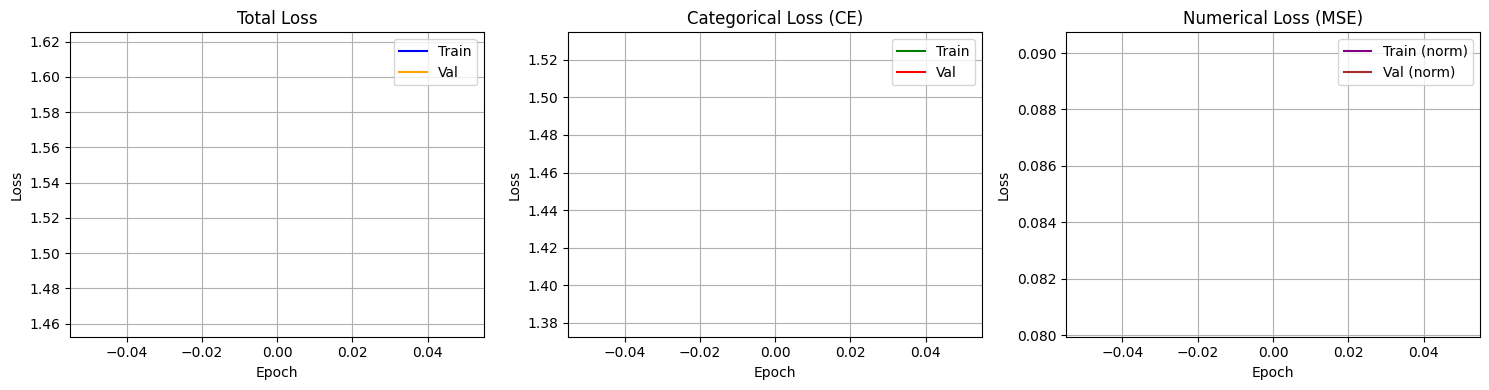

💾 Model saved to tabbert_new/tabbert_model_mlm_no_history_epoch_2.pth


Epoch 2/10 (Train):  25%|██▌       | 9653/38105 [40:21<1:56:35,  4.07it/s, total=1.6099, cat=1.5649, num=0.0449]

In [ ]:
print("🚀 Начинаем обучение MLM...")
print("="*70)

for epoch in range(epochs):
    # ========== TRAINING ==========
    mlm_model.train()

    total_train_loss = 0
    total_train_cat_loss = 0
    total_train_num_loss = 0
    num_batches = 0

    # Для сбора потерь по полям
    field_losses_sum = {field: 0.0 for field in train_field_losses.keys()}
    field_counts = {field: 0 for field in train_field_losses.keys()}

    progress_bar = tqdm(mlm_loader, desc=f'Epoch {epoch+1}/{epochs} (Train)')

    for step, batch in enumerate(progress_bar, start=1):
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            prediction_scores, num_scores, all_cat_labels, all_num_labels = mlm_model.forward_mlm(
                    batch['current_cat_ids'].to(device),
                    batch['current_num_values'].to(device),
                    batch['current_mask'].to(device),
                    batch['current_cat_labels'].to(device),
                    batch['current_num_labels'].to(device),
                )


            total_loss, cat_loss, num_loss, field_losses = calculate_mlm_loss(
                prediction_scores,
                all_cat_labels,
                num_scores,
                all_num_labels,
                field_ranges,
                num_normalizer=num_normalizer
            )

        if scaler.is_enabled():
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), max_norm=1.0)
            optimizer.step()

        # Сбор статистики
        total_train_loss += total_loss.item()
        total_train_cat_loss += cat_loss.item() if isinstance(cat_loss, torch.Tensor) else cat_loss
        total_train_num_loss += num_loss.item() if isinstance(num_loss, torch.Tensor) else num_loss
        num_batches += 1

        # Сбор потерь по полям
        for field_name, loss_val in field_losses.items():
            if field_name in field_losses_sum:
                field_losses_sum[field_name] += loss_val
                field_counts[field_name] += 1

        if step % POSTFIX_EVERY == 0 or step == len(mlm_loader):
            progress_bar.set_postfix({
                'total': f'{total_loss.item():.4f}',
                'cat': f'{cat_loss.item():.4f}',
                'num': f'{num_loss.item():.4f}'
            })

    # Усредняем потери за эпоху
    avg_train_loss = total_train_loss / num_batches
    avg_train_cat_loss = total_train_cat_loss / num_batches
    avg_train_num_loss = total_train_num_loss / num_batches

    train_total_losses.append(avg_train_loss)
    train_cat_losses.append(avg_train_cat_loss)
    train_num_losses.append(avg_train_num_loss)

    # Сохраняем потери по полям
    for field_name in field_losses_sum:
        if field_counts[field_name] > 0:
            avg_field_loss = field_losses_sum[field_name] / field_counts[field_name]
            train_field_losses[field_name].append(avg_field_loss)

    print(f'\n📈 Epoch {epoch+1} - Train: Total={avg_train_loss:.4f}, '
          f'CE={avg_train_cat_loss:.4f}, MSE={avg_train_num_loss:.4f}')

    # ========== VALIDATION ==========
    mlm_model.eval()

    total_val_loss = 0
    total_val_cat_loss = 0
    total_val_num_loss = 0
    num_val_batches = 0

    val_field_losses_sum = {field: 0.0 for field in val_field_losses.keys()}
    val_field_counts = {field: 0 for field in val_field_losses.keys()}

    with torch.no_grad():
        val_progress_bar = tqdm(mlm_val_loader, desc=f'Epoch {epoch+1}/{epochs} (Val)')

        for step, batch in enumerate(val_progress_bar, start=1):
            batch = move_batch_to_device(batch, device)

            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                prediction_scores, num_scores, all_cat_labels, all_num_labels = mlm_model.forward_mlm(
                    batch['current_cat_ids'].to(device),
                    batch['current_num_values'].to(device),
                    batch['current_mask'].to(device),
                    batch['current_cat_labels'].to(device),
                    batch['current_num_labels'].to(device),
                )


                total_loss, cat_loss, num_loss, field_losses = calculate_mlm_loss(
                    prediction_scores,
                    all_cat_labels,
                    num_scores,
                    all_num_labels,
                    field_ranges,
                    num_normalizer=num_normalizer
                )

            # Сбор статистики
            total_val_loss += total_loss.item()
            total_val_cat_loss += cat_loss.item() if isinstance(cat_loss, torch.Tensor) else cat_loss
            total_val_num_loss += num_loss.item() if isinstance(num_loss, torch.Tensor) else num_loss
            num_val_batches += 1

            # Сбор потерь по полям
            for field_name, loss_val in field_losses.items():
                if field_name in val_field_losses_sum:
                    val_field_losses_sum[field_name] += loss_val
                    val_field_counts[field_name] += 1

            if step % POSTFIX_EVERY == 0 or step == len(mlm_val_loader):
                val_progress_bar.set_postfix({
                    'total': f'{total_loss.item():.4f}',
                    'cat': f'{cat_loss.item():.4f}',
                    'num': f'{num_loss.item():.4f}'
                })

    # Усредняем потери за эпоху
    avg_val_loss = total_val_loss / num_val_batches
    avg_val_cat_loss = total_val_cat_loss / num_val_batches
    avg_val_num_loss = total_val_num_loss / num_val_batches

    val_total_losses.append(avg_val_loss)
    val_cat_losses.append(avg_val_cat_loss)
    val_num_losses.append(avg_val_num_loss)

    # Сохраняем потери по полям
    for field_name in val_field_losses_sum:
        if val_field_counts[field_name] > 0:
            avg_field_loss = val_field_losses_sum[field_name] / val_field_counts[field_name]
            val_field_losses[field_name].append(avg_field_loss)

    print(f'📉 Epoch {epoch+1} - Val:   Total={avg_val_loss:.4f}, '
          f'CE={avg_val_cat_loss:.4f}, MSE={avg_val_num_loss:.4f}')

    # Обновляем learning rate
    # scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'📚 Learning Rate: {current_lr:.2e}')
    print('-' * 70)

    # Отрисовка графиков
    plot_all_losses_normalized(train_total_losses, val_total_losses,
                    train_cat_losses, val_cat_losses,
                    train_num_losses, val_num_losses)

    # Сохранение модели
    save_path = f"tabbert_new/tabbert_model_mlm_no_history_epoch_{epoch+2}.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': mlm_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_total_losses': train_total_losses,
        'val_total_losses': val_total_losses,
        'train_cat_losses': train_cat_losses,
        'val_cat_losses': val_cat_losses,
        'train_num_losses': train_num_losses,
        'val_num_losses': val_num_losses,
    }, save_path)
    print(f'💾 Model saved to {save_path}')


print("\n✅ Обучение завершено!")
print("="*70)

In [ ]:
class TabBertFraudDataset(Dataset):
    """Dataset для fine-tuning на fraud detection (только одна транзакция)."""

    def __init__(self, df, tokenizer, categorical_columns, numerical_columns,
                 label_col='is_fraud', max_seq_length=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.categorical_columns = categorical_columns
        self.numerical_columns = numerical_columns
        self.label_col = label_col
        self.max_seq_length = max_seq_length

        self.cls_id = self.tokenizer.vocab['[CLS]']
        self.sep_id = self.tokenizer.vocab['[SEP]']
        self.pad_id = self.tokenizer.vocab['[PAD]']
        self.unk_id = self.tokenizer.vocab['[UNK]']
        self.num_numerical_features = len(self.numerical_columns)

        # Используем массивы колонок для быстрого доступа
        used_columns = list(dict.fromkeys(
            [self.label_col] + self.categorical_columns + self.numerical_columns
        ))
        self.column_arrays = {
            col: self.df[col].to_numpy(copy=False) for col in used_columns
        }

        # Pre-allocate arrays for padding (used for invalid indices)
        self.pad_cat_ids = np.full(self.max_seq_length, self.pad_id, dtype=np.int64)
        self.pad_num_values = np.zeros(self.num_numerical_features, dtype=np.float32)
        self.pad_mask = np.zeros(self.max_seq_length, dtype=np.int64)

        # Build mapping from categorical values to token IDs
        self.cat_value_to_id = {col: {} for col in self.categorical_columns}
        for token, token_id in self.tokenizer.vocab.items():
            if token.startswith('['):
                continue
            col_name, sep, value = token.partition('_')
            if sep and col_name in self.cat_value_to_id:
                self.cat_value_to_id[col_name][value] = token_id

        print(f"Создано {len(self.df)} транзакций")

    def _tokenize_transaction(self, idx):
        """Токенизация одной транзакции."""
        if idx is None or idx < 0:
            return self.pad_cat_ids.copy(), self.pad_num_values.copy(), self.pad_mask.copy()

        cat_ids = self.pad_cat_ids.copy()
        num_values = self.pad_num_values.copy()
        mask = self.pad_mask.copy()

        write_pos = 0
        cat_ids[write_pos] = self.cls_id
        write_pos += 1

        # Добавляем категориальные признаки
        for col in self.categorical_columns:
            if write_pos >= self.max_seq_length - 1:
                break

            value = self.column_arrays[col][idx]
            if pd.isna(value):
                token_id = self.unk_id
            else:
                token_id = self.cat_value_to_id[col].get(str(value), self.unk_id)

            cat_ids[write_pos] = token_id
            write_pos += 1

        # Добавляем SEP
        if write_pos < self.max_seq_length:
            cat_ids[write_pos] = self.sep_id
            write_pos += 1

        # Маска внимания
        mask[:write_pos] = 1

        # Числовые признаки
        for num_idx, col in enumerate(self.numerical_columns):
            value = self.column_arrays[col][idx]
            num_values[num_idx] = 0.0 if pd.isna(value) else float(value)

        return cat_ids, num_values, mask

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """Возвращает одну транзакцию."""
        cat_ids, num_values, mask = self._tokenize_transaction(idx)
        label = int(self.column_arrays[self.label_col][idx])


        return {
            'cat_ids': torch.from_numpy(cat_ids).unsqueeze(0).long(),  # [1, seq_len]
            'num_values': torch.from_numpy(num_values).unsqueeze(0).float(),  # [1, num_features]
            'attention_mask': torch.from_numpy(mask).unsqueeze(0).long(),  # [1, seq_len]
            'labels': torch.tensor(label, dtype=torch.long)  # [1]
        }

In [12]:
import pandas as pd

def split_by_time_per_user(
    df,
    user_col="user",
    time_col="timestamp",
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    df = df.sort_values([user_col, time_col]).reset_index(drop=True)

    train_parts = []
    val_parts = []
    test_parts = []

    for _, group in df.groupby(user_col, sort=False):
        n = len(group)

        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        # чтобы не развалиться на маленьких группах
        if train_end == 0:
            train_end = min(1, n)
        if val_end <= train_end and n - train_end > 1:
            val_end = train_end + 1

        train_parts.append(group.iloc[:train_end])
        val_parts.append(group.iloc[train_end:val_end])
        test_parts.append(group.iloc[val_end:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, val_df, test_df

In [13]:
train_df, val_df, test_df = split_by_time_per_user(
    df,
    user_col="user",
    time_col="timestamp",
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
)

print(len(train_df), len(val_df), len(test_df))
print(len(train_df) / len(df), len(val_df) / len(df), len(test_df) / len(df))

17069880 3657092 3659928
0.6999610446592228 0.14996133169857587 0.15007762364220134


In [14]:
train_dataset = TabBertFraudDataset(
    train_df, tokenizer, categorical_columns, numerical_columns, 
    max_seq_length=18, 
)

val_dataset = TabBertFraudDataset(
    val_df, tokenizer, categorical_columns, numerical_columns, 
    max_seq_length=18, 
)

test_dataset = TabBertFraudDataset(
    test_df, tokenizer, categorical_columns, numerical_columns, 
    max_seq_length=18, 
)

Создано 17069880 транзакций
Создано 3657092 транзакций
Создано 3659928 транзакций


In [49]:
# del fraud_train_loader, fraud_val_loader, fraud_test_loader

In [16]:
import os

from torch.utils.data import random_split

torch.manual_seed(42)


print(f"Train samples: {len(train_dataset)} ")
print(f"Val samples: {len(val_dataset)} ")
print(f"Test samples: {len(test_dataset)}")

AVAILABLE_CPU = os.cpu_count() or 2
NUM_WORKERS = min(8, max(2, AVAILABLE_CPU - 2))
BATCH_SIZE = 2048
PIN_MEMORY = device.type == 'cuda'

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'persistent_workers': NUM_WORKERS > 0,
    'drop_last': False
}

if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 4

fraud_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs
)

fraud_val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

fraud_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

print(f"\nCPU cores available: {AVAILABLE_CPU}")
print(f"Using DataLoader workers: {NUM_WORKERS}")


Train samples: 17069880 
Val samples: 3657092 
Test samples: 3659928

CPU cores available: 44
Using DataLoader workers: 8


In [18]:
import os
import torch
from copy import deepcopy
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


def _safe_binary_auc(y_true, y_score):
    """Безопасный расчет AUC: возвращает NaN, если в выборке только один класс."""
    unique_classes = np.unique(y_true)
    if unique_classes.shape[0] < 2:
        return float('nan')
    return roc_auc_score(y_true, y_score)


def train_tabbert(
    model,
    train_loader,
    val_loader,
    epochs=5,
    device='cuda',
    save_dir='tabbert_new',
    save_prefix='tabbert_no_history_v2'
):
    """Fine-tuning для fraud detection в полном FP32 с early stopping и scheduler по val F1."""
    model = model.to(device)
    os.makedirs(save_dir, exist_ok=True)

    optimizer = torch.optim.AdamW([
        {'params': model.cat_embedding.parameters(), 'lr': 1e-5},
        {'params': model.num_projection.parameters(), 'lr': 1e-5},
        {'params': model.transformer.parameters(), 'lr': 1e-5},
        {'params': model.classifier.parameters(), 'lr': 2e-5},
    ], weight_decay=0.1)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=2
    )

    best_val_f1 = 0.0
    patience = 5
    patience_counter = 0
    best_model_state = None

    history = {
        'train_loss': [], 'val_loss': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc': [], 'val_auc': []
    }

    for epoch in range(epochs):
        print(f"\n{'=' * 50}")
        print(f"Эпоха {epoch + 1}/{epochs}")
        print('=' * 50)

        model.train()
        train_loss = 0.0
        train_preds = []
        train_probs = []
        train_labels = []

        train_bar = tqdm(train_loader, desc='Training')
        for batch in train_bar:
            cat_ids = batch['cat_ids'].to(device, non_blocking=True)
            num_values = batch['num_values'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            loss, logits = model(
                cat_ids=cat_ids,
                num_values=num_values,
                attention_mask=attention_mask,
                labels=labels
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

            probs = torch.softmax(logits, dim=-1)
            preds = logits.argmax(dim=-1)
            valid_mask = (labels != -100)

            valid_preds = preds[valid_mask].detach().cpu().numpy()
            valid_probs = probs[..., 1][valid_mask].detach().cpu().numpy()
            valid_labels = labels[valid_mask].detach().cpu().numpy()

            train_preds.extend(valid_preds.tolist())
            train_probs.extend(valid_probs.tolist())
            train_labels.extend(valid_labels.tolist())

            train_bar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = train_loss / len(train_loader)
        train_precision = precision_score(train_labels, train_preds, zero_division=0)
        train_recall = recall_score(train_labels, train_preds, zero_division=0)
        train_f1 = f1_score(train_labels, train_preds, zero_division=0)
        train_auc = _safe_binary_auc(np.array(train_labels), np.array(train_probs))

        model.eval()
        val_loss = 0.0
        val_preds = []
        val_probs = []
        val_labels = []

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc='Validation')
            for batch in val_bar:
                cat_ids = batch['cat_ids'].to(device, non_blocking=True)
                num_values = batch['num_values'].to(device, non_blocking=True)
                attention_mask = batch['attention_mask'].to(device, non_blocking=True)
                labels = batch['labels'].to(device, non_blocking=True)

                loss, logits = model(
                    cat_ids=cat_ids,
                    num_values=num_values,
                    attention_mask=attention_mask,
                    labels=labels
                )

                val_loss += loss.item()

                probs = torch.softmax(logits, dim=-1)
                preds = logits.argmax(dim=-1)
                valid_mask = (labels != -100)

                valid_preds = preds[valid_mask].detach().cpu().numpy()
                valid_probs = probs[..., 1][valid_mask].detach().cpu().numpy()
                valid_labels_batch = labels[valid_mask].detach().cpu().numpy()

                val_preds.extend(valid_preds.tolist())
                val_probs.extend(valid_probs.tolist())
                val_labels.extend(valid_labels_batch.tolist())

                val_bar.set_postfix(loss=f'{loss.item():.4f}')

        val_loss = val_loss / len(val_loader)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        val_auc = _safe_binary_auc(np.array(val_labels), np.array(val_probs))

        scheduler.step(val_f1)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_precision'].append(train_precision)
        history['val_precision'].append(val_precision)
        history['train_recall'].append(train_recall)
        history['val_recall'].append(val_recall)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)

        print(f"\n📊 РЕЗУЛЬТАТЫ ЭПОХИ {epoch + 3}:")
        print(f"  Train - Loss: {train_loss:.4f}")
        print(f"          Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
        print(f"          AUC: {train_auc:.4f}" if not np.isnan(train_auc) else "          AUC: nan")
        print(f"  Val   - Loss: {val_loss:.4f}")
        print(f"          Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
        print(f"          AUC: {val_auc:.4f}" if not np.isnan(val_auc) else "          AUC: nan")

        val_probs_array = np.array(val_probs)
        val_labels_array = np.array(val_labels)
        print(f"\n📈 Статистика вероятностей (val):")
        print(f"  Всего: min={val_probs_array.min():.4f}, max={val_probs_array.max():.4f}, mean={val_probs_array.mean():.4f}")

        fraud_mask = val_labels_array == 1
        if fraud_mask.sum() > 0:
            print(f"  Фрод (класс 1): mean={val_probs_array[fraud_mask].mean():.4f}, max={val_probs_array[fraud_mask].max():.4f}")

        non_fraud_mask = val_labels_array == 0
        if non_fraud_mask.sum() > 0:
            print(f"  Не-фрод (класс 0): mean={val_probs_array[non_fraud_mask].mean():.4f}, max={val_probs_array[non_fraud_mask].max():.4f}")
        print('-' * 50)

        checkpoint_path = os.path.join(save_dir, f"{save_prefix}_epoch_{epoch}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'history': history,
            'val_metrics': {
                'loss': val_loss,
                'precision': val_precision,
                'recall': val_recall,
                'f1': val_f1,
                'auc': val_auc,
            },
            'train_metrics': {
                'loss': train_loss,
                'precision': train_precision,
                'recall': train_recall,
                'f1': train_f1,
                'auc': train_auc,
            }
        }, checkpoint_path)
        print(f"💾 Сохранен checkpoint: {checkpoint_path}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
            print(f"✅ НОВЫЙ ЛУЧШИЙ F1: {best_val_f1:.4f}")

            best_model_path = os.path.join(save_dir, f"{save_prefix}_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': best_model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_f1': best_val_f1,
                'history': history,
                'val_metrics': {
                    'loss': val_loss,
                    'precision': val_precision,
                    'recall': val_recall,
                    'f1': val_f1,
                    'auc': val_auc,
                }
            }, best_model_path)
            print(f"🏆 Сохранена лучшая модель: {best_model_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"🛑 Ранняя остановка на эпохе {epoch + 1}")
                # break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n🏆 Загружена лучшая модель с F1 = {best_val_f1:.4f}")

    return model, history


def plot_training_history(history):
    """Построение графиков обучения."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(epochs, history['train_f1'], 'b-o', label='Train F1', linewidth=2)
    axes[0, 1].plot(epochs, history['val_f1'], 'r-o', label='Val F1', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[0, 2].plot(epochs, history['train_auc'], 'b-o', label='Train AUC', linewidth=2)
    axes[0, 2].plot(epochs, history['val_auc'], 'r-o', label='Val AUC', linewidth=2)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('AUC')
    axes[0, 2].set_title('AUC-ROC')
    axes[0, 2].legend()
    axes[0, 2].grid(True)

    axes[1, 0].plot(epochs, history['train_precision'], 'b-o', label='Train Precision', linewidth=2)
    axes[1, 0].plot(epochs, history['val_precision'], 'r-o', label='Val Precision', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_title('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(epochs, history['train_recall'], 'b-o', label='Train Recall', linewidth=2)
    axes[1, 1].plot(epochs, history['val_recall'], 'r-o', label='Val Recall', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_title('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)


In [ ]:
new_model, history = train_tabbert(
    mlm_model,
    fraud_train_loader,
    fraud_val_loader,
    epochs=20,)


Эпоха 1/20


Validation: 100%|██████████| 1786/1786 [01:00<00:00, 29.52it/s, loss=0.0027]



📊 РЕЗУЛЬТАТЫ ЭПОХИ 3:
  Train - Loss: 0.0398
          Precision: 0.0000, Recall: 0.0000, F1: 0.0000
          AUC: 0.8667
  Val   - Loss: 0.0189
          Precision: 0.0000, Recall: 0.0000, F1: 0.0000
          AUC: 0.9618

📈 Статистика вероятностей (val):
  Всего: min=0.0001, max=0.4633, mean=0.0020
  Фрод (класс 1): mean=0.2635, max=0.4633
  Не-фрод (класс 0): mean=0.0016, max=0.4633
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_new/tabbert_no_history_v2_epoch_0.pth

Эпоха 2/20


Validation: 100%|██████████| 1786/1786 [00:45<00:00, 39.37it/s, loss=0.0033]



📊 РЕЗУЛЬТАТЫ ЭПОХИ 4:
  Train - Loss: 0.0182
          Precision: 0.4494, Recall: 0.3002, F1: 0.3599
          AUC: 0.9316
  Val   - Loss: 0.0148
          Precision: 0.5240, Recall: 0.6169, F1: 0.5667
          AUC: 0.9694

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.8502, mean=0.0025
  Фрод (класс 1): mean=0.5181, max=0.8502
  Не-фрод (класс 0): mean=0.0018, max=0.8474
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_new/tabbert_no_history_v2_epoch_1.pth
✅ НОВЫЙ ЛУЧШИЙ F1: 0.5667
🏆 Сохранена лучшая модель: tabbert_new/tabbert_no_history_v2_best.pth

Эпоха 3/20


...

Validation: 100%|██████████| 1786/1786 [00:44<00:00, 39.72it/s, loss=0.0011]



📊 РЕЗУЛЬТАТЫ ЭПОХИ 11:
  Train - Loss: 0.0119
          Precision: 0.7931, Recall: 0.6542, F1: 0.7170
          AUC: 0.9601
  Val   - Loss: 0.0101
          Precision: 0.7605, Recall: 0.7247, F1: 0.7422
          AUC: 0.9841

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.9987, mean=0.0021
  Фрод (класс 1): mean=0.7228, max=0.9987
  Не-фрод (класс 0): mean=0.0011, max=0.9978
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_new/tabbert_no_history_v2_epoch_8.pth

Эпоха 10/20


Validation: 100%|██████████| 1786/1786 [00:54<00:00, 32.89it/s, loss=0.0013]



📊 РЕЗУЛЬТАТЫ ЭПОХИ 12:
  Train - Loss: 0.0116
          Precision: 0.8071, Recall: 0.6581, F1: 0.7250
          AUC: 0.9632
  Val   - Loss: 0.0099
          Precision: 0.7856, Recall: 0.7291, F1: 0.7563
          AUC: 0.9859

📈 Статистика вероятностей (val):
  Всего: min=0.0000, max=0.9984, mean=0.0020
  Фрод (класс 1): mean=0.7273, max=0.9984
  Не-фрод (класс 0): mean=0.0010, max=0.9974
--------------------------------------------------
💾 Сохранен checkpoint: tabbert_new/tabbert_no_history_v2_epoch_9.pth

Эпоха 11/20


Training:   4%|▎         | 309/8335 [00:23<09:33, 14.00it/s, loss=0.0179]

In [27]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


def safe_binary_auc(y_true, y_score):
    unique_classes = np.unique(y_true)
    if unique_classes.shape[0] < 2:
        return float('nan')
    return roc_auc_score(y_true, y_score)


def collect_model_probs(model, loader, device='cuda'):
    model.eval()
    model = model.to(device)

    use_amp_local = str(device).startswith('cuda') and torch.cuda.is_available()

    all_probs = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Collecting probs"):
            cat_ids = batch['cat_ids'].to(device, non_blocking=True)
            num_values = batch['num_values'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp_local):
                loss, logits = model(
                    cat_ids=cat_ids,
                    num_values=num_values,
                    attention_mask=attention_mask,
                    labels=labels
                )

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=-1)[..., 1]
            valid_mask = (labels != -100)

            batch_probs = probs[valid_mask].detach().cpu().numpy()
            batch_labels = labels[valid_mask].detach().cpu().numpy()

            all_probs.extend(batch_probs.tolist())
            all_labels.extend(batch_labels.tolist())

    avg_loss = total_loss / len(loader)

    return np.array(all_probs), np.array(all_labels), avg_loss


def compute_metrics_at_threshold(y_true, y_prob, threshold=0.5, loss=None):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'threshold': threshold,
        'loss': loss,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': safe_binary_auc(y_true, y_prob)
    }


def find_best_threshold(y_true, y_prob, loss=None, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    best_metrics = None
    best_f1 = -1.0

    for thr in thresholds:
        metrics = compute_metrics_at_threshold(y_true, y_prob, threshold=thr, loss=loss)
        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_metrics = metrics

    return best_metrics


# 1. Собираем вероятности на validation
val_probs, val_labels, val_loss = collect_model_probs(mlm_model, fraud_val_loader, device=device)

# 2. Ищем лучший threshold по val F1
best_val_metrics = find_best_threshold(val_labels, val_probs, loss=val_loss)
best_threshold = best_val_metrics['threshold']

print(f"Best threshold on val: {best_threshold:.2f}")
print("Validation metrics at best threshold:")
print(best_val_metrics)

# 3. Считаем test метрики с этим threshold
test_probs, test_labels, test_loss = collect_model_probs(mlm_model, fraud_test_loader, device=device)
test_metrics = compute_metrics_at_threshold(test_labels, test_probs, threshold=best_threshold, loss=test_loss)

print("\nTest metrics with validation-selected threshold:")
print(test_metrics)

Best threshold on val: 0.71
Validation metrics at best threshold:
{'threshold': np.float64(0.7100000000000002), 'loss': 0.009204244892829947, 'precision': 0.8550071191267204, 'recall': 0.7256797583081571, 'f1': 0.7850528379997821, 'auc': np.float64(0.9889286103833117)}



Test metrics with validation-selected threshold:
{'threshold': np.float64(0.7100000000000002), 'loss': 0.00430045365575327, 'precision': 0.8332914256977622, 'recall': 0.8078985860555826, 'f1': 0.820398564178735, 'auc': np.float64(0.9975274499325151)}
